# Lab 3a: Ray Parameter Computation — 2D FSM

In this lab, you will learn how to compute source–receiver ray parameters (traveltime, takeoff angle, azimuth, ray distance) using a **2D Fast Sweeping Method (FSM)** with topography:

- Load event catalog, velocity model, topography, and receiver geometry
- Build a local Cartesian grid with topographic surface
- Compute 2D radial traveltime fields for each receiver
- Interpolate ray parameters from cylindrical catalogs to event locations
- Subsample DAS fiber and interpolate to all channels

**References:**
- Zhao, H. (2005). A fast sweeping method for Eikonal equations. *Math. Comp.*, 74(250), 603–627.
- Li, J., Zhu, W., Biondi, E., & Zhan, Z. (2023). Earthquake focal mechanisms with distributed acoustic sensing. *Nature Communications*, 14, 4181.

## Setup

Import libraries and set the project directory.

In [ ]:
from pathlib import Path
import shutil
import time
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import uniform_filter1d
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

PROJECT_DIR    = Path("../Inputs/proj_25events")
print(f"Project: {PROJECT_DIR.resolve()}")

## 1. Load Input Data

Load the event catalog, 1D velocity model, topography DEM, and receiver geometries (traditional stations and DAS fiber channels).

- **Topography** — DEM from [OpenTopography](https://opentopography.org/), used to define the surface boundary in the 2D cross-section solver

In [36]:
from dasfm.io.velocity_io import load_velocity_1d
from dasfm.io.topo_io import load_topo

EVENT_CATALOG  = "input/catalog_25events.csv"
VEL_1D         = "input/1D_velocity_MAM.txt"
TOPO           = "input/SRTMGL1_LongValley.tif"    # supports .tif or .h5
STA_GEO        = "input/all_stations.csv"
DAS_GEO        = "input/das_info.csv"

catalog = pd.read_csv(PROJECT_DIR / EVENT_CATALOG)
vel_depth, vel_vp = load_velocity_1d(PROJECT_DIR / VEL_1D)
elev_lat, elev_lon, elev = load_topo(PROJECT_DIR / TOPO)

print(f"Events: {len(catalog)}")
print(f"Velocity model: {len(vel_depth)} layers, Vp = {vel_vp.min():.2f}-{vel_vp.max():.2f} km/s")
print(f"Topography: {elev.shape}")

# -- STA receivers --
sta_df = pd.read_csv(PROJECT_DIR / STA_GEO)
sta_unique = sta_df.drop_duplicates(subset=["network", "station"])
sta_lat = sta_unique["latitude"].values
sta_lon = sta_unique["longitude"].values
n_sta = len(sta_unique)
print(f"Stations: {n_sta} (unique)")

# -- DAS receivers --
das_info = pd.read_csv(PROJECT_DIR / DAS_GEO)
das_lat = das_info["latitude"].values
das_lon = das_info["longitude"].values
n_ch = len(das_info)
print(f"DAS channels: {n_ch}")

Events: 25
Velocity model: 16 layers, Vp = 3.61-6.83 km/s
Topography: (7200, 9000)
Stations: 38 (unique)
DAS channels: 4670


## 2. Build Cartesian Grid

Project all geographic coordinates (lat/lon) onto a local Cartesian grid (x = northing, y = easting, z = depth).

- **Grid spacing** — uniform resolution for all three dimensions
- **Horizontal extent** — bounding box of all sources and receivers, plus padding
- **Vertical extent** — from the highest terrain elevation down to max depth
- **Topographic surface** — interpolated from DEM onto grid nodes


[build_model_grid]  origin (37.57345°N, -118.82709°E)
  x (north) [0.00 … 87.20] km  nx=437  dx=0.2 km
  y (east)  [0.00 … 87.40] km  ny=438  dy=0.2 km
  z (depth) [0.00 … 30.80] km  nz=155  dz=0.2 km
  h_max=4.310 km  (z=0 ↔ 4.310 km a.s.l., sea level at z=4.310 km)
  n_events=25  n_receivers=38
[build_model_grid]  origin (37.59650°N, -118.76538°E)
  x (north) [0.00 … 25.20] km  nx=127  dx=0.2 km
  y (east)  [0.00 … 34.20] km  ny=172  dy=0.2 km
  z (depth) [0.00 … 30.60] km  nz=154  dz=0.2 km
  h_max=3.968 km  (z=0 ↔ 3.968 km a.s.l., sea level at z=3.968 km)
  n_events=25  n_receivers=4670


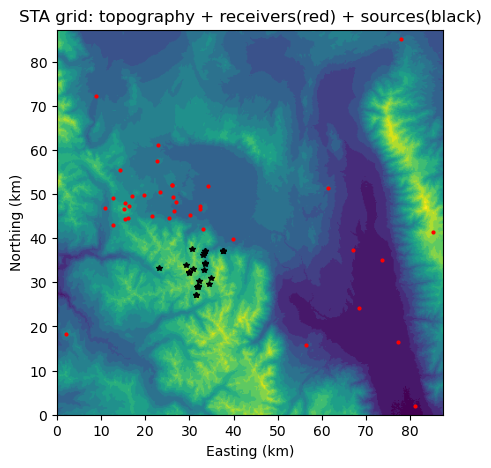

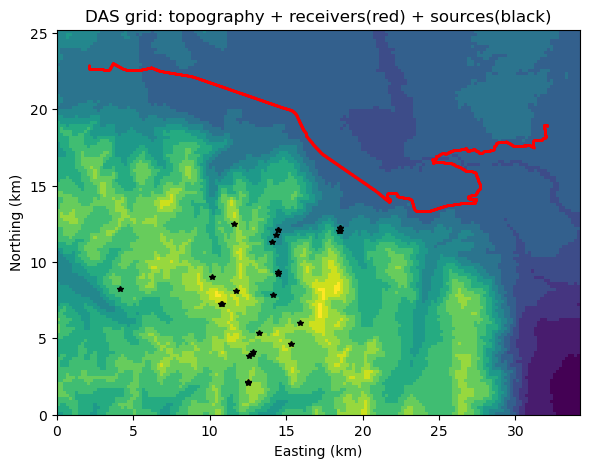

In [37]:
from dasfm.forward.geometry import build_model_grid


dr  = 0.2


depth_col = "depth" if "depth" in catalog.columns else "depth_km"
depth_max = float(catalog[depth_col].max()) * 2

geo_sta = build_model_grid(
    catalog, receiver_lat=sta_lat, receiver_lon=sta_lon,
    topo_lat=elev_lat, topo_lon=elev_lon, topo_elev_m=elev,
    depth_max=depth_max, dx=dr, dy=dr, dz=dr,
)

geo_das = build_model_grid(
    catalog, receiver_lat=das_lat, receiver_lon=das_lon,
    topo_lat=elev_lat, topo_lon=elev_lon, topo_elev_m=elev,
    depth_max=depth_max, dx=dr, dy=dr, dz=dr,
)

# Grid QC (STA) — plot receivers/sources at their exact physical positions
plt.figure(figsize=(10, 5))
x_grid_sta = geo_sta['x_grid']; y_grid_sta = geo_sta['y_grid']
elev_sta_m = (geo_sta['h_max'] - geo_sta['z_grid'][geo_sta['surface_iz']]) * 1000
plt.imshow(elev_sta_m, origin='lower', cmap='gist_earth',
           extent=[y_grid_sta[0], y_grid_sta[-1], x_grid_sta[0], x_grid_sta[-1]])
plt.colorbar(label="Elevation (m)")
plt.plot(geo_sta['receiver_y'], geo_sta['receiver_x'], 'r.', ms=4)
plt.plot(geo_sta['source_y'], geo_sta['source_x'], 'k*', ms=4)
plt.xlabel("Easting (km)"); plt.ylabel("Northing (km)")
plt.title("STA grid: topography + receivers(red) + sources(black)")
plt.show()

# Grid QC (DAS) — plot receivers/sources at their exact physical positions
plt.figure(figsize=(10, 5))
x_grid_das = geo_das['x_grid']; y_grid_das = geo_das['y_grid']
elev_das_m = (geo_das['h_max'] - geo_das['z_grid'][geo_das['surface_iz']]) * 1000
plt.imshow(elev_das_m, origin='lower', cmap='gist_earth',
           extent=[y_grid_das[0], y_grid_das[-1], x_grid_das[0], x_grid_das[-1]])
plt.colorbar(label="Elevation (m)")
plt.plot(geo_das['receiver_y'], geo_das['receiver_x'], 'r.', ms=1)
plt.plot(geo_das['source_y'], geo_das['source_x'], 'k*', ms=4)
plt.xlabel("Easting (km)"); plt.ylabel("Northing (km)")
plt.title("DAS grid: topography + receivers(red) + sources(black)")
plt.show()

## 3. Radial Sampling Visualization

The 2D FSM computes traveltime on **radial cross-sections** centered at each receiver. Each azimuth produces a 2D vertical slice (depth x radial distance) through the velocity model with topography. The slices are spaced 5 degrees apart and cover 0-360 degrees.

- The receiver acts as the center of a cylindrical coordinate system
- Orange lines show the azimuthal sampling directions from the first station
- The background image shows the topographic surface grid 

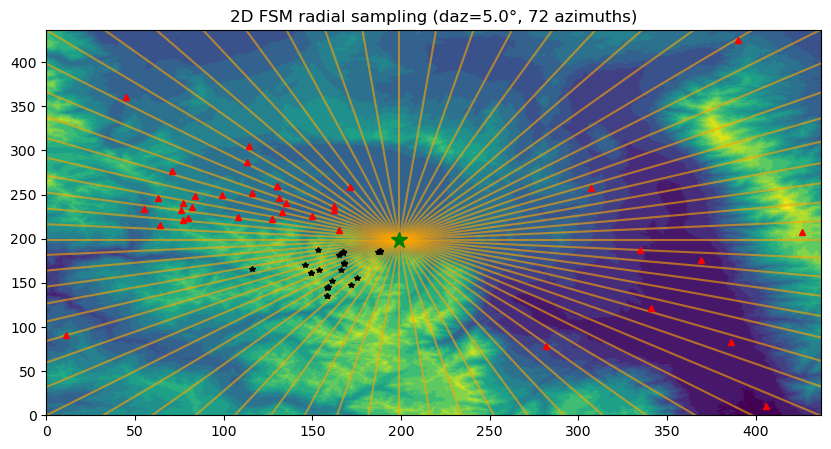

In [38]:
daz = 5.0  # azimuth interpolation spacing (degrees)

az_angles = np.arange(0.0, 360.0, daz)


sta0 = 0  # first station as reference

# Line length = distance from receiver to farthest grid corner (in grid indices)
rx_ix, rx_iy = geo_sta['receiver_ix'][sta0], geo_sta['receiver_iy'][sta0]
line_len = max(
    np.hypot(rx_ix, rx_iy),
    np.hypot(rx_ix, geo_sta['ny'] - 1 - rx_iy),
    np.hypot(geo_sta['nx'] - 1 - rx_ix, rx_iy),
    np.hypot(geo_sta['nx'] - 1 - rx_ix, geo_sta['ny'] - 1 - rx_iy),
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(elev_sta_m, aspect='auto', origin='lower', cmap='gist_earth')
for az_deg in az_angles:
    az_rad = np.radians(az_deg)
    end_iy = rx_iy + line_len * np.sin(az_rad)
    end_ix = rx_ix + line_len * np.cos(az_rad)
    ax.plot([rx_iy, end_iy], [rx_ix, end_ix],
            color='orange', lw=1.5, alpha=0.6)
ax.plot(geo_sta['receiver_iy'], geo_sta['receiver_ix'], 'r^', ms=4)
ax.plot(geo_sta['source_iy'], geo_sta['source_ix'], 'k*', ms=4)
ax.plot(rx_iy, rx_ix, 'g*', ms=12, zorder=10)
ax.set_xlim(0, geo_sta['ny'] - 1)
ax.set_ylim(0, geo_sta['nx'] - 1)
ax.set_title(f'2D FSM radial sampling (daz={daz}\u00b0, {len(az_angles)} azimuths)')
plt.show()

## 4. Compute Ray Catalog — Traditional Stations (2D FSM)

For each receiver, the 2D FSM solves the Eikonal equation on radial cross-sections to build a **ray catalog** — a 3D lookup table in cylindrical coordinates (z, r, azimuth) containing:

- P-wave traveltime [s]
- takeoff angle [rad] (0 = downward, pi = upward)
- ray path distance [km]

The 3D scatter plot visualizes the traveltime field from a single station, showing how traveltime increases with distance from the receiver.

[Demo] Computing 2-D lookup table for station 20 (of 38 total)...
[Demo] Station 20 lookup computed: geometry=cyl_2d


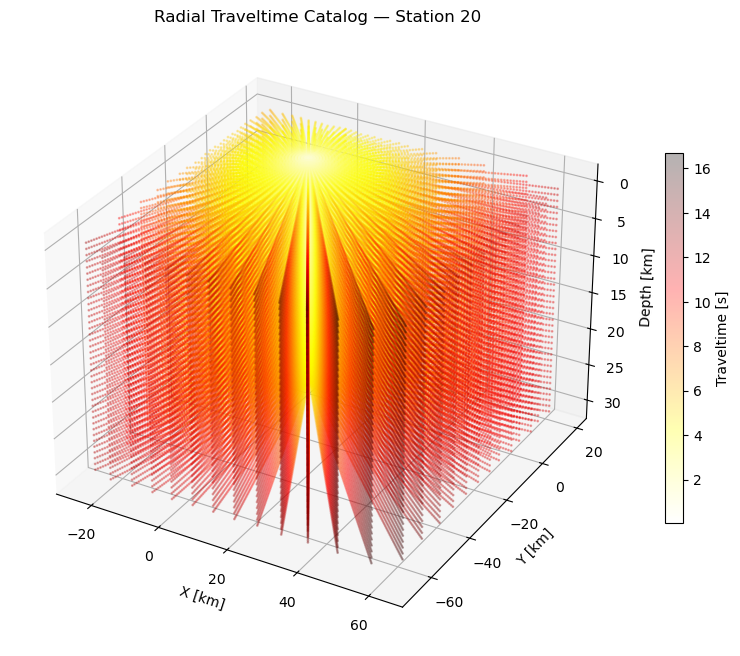

In [39]:
# calculate ray parameter catalog — DEMO: compute 1 station
from dasfm.forward.ray_lookup_2d import compute_ray_lookup
from dasfm.io.data import RayParamDB

CACHE_DIR = PROJECT_DIR / "cache"
DEMO_STATION = 20  # <-- change this to compute a different station

dr  = 0.2
daz = 5.0  # azimuth interpolation spacing (deg)

source_x = np.asarray(geo_sta["source_x"], dtype=np.float64).ravel()
source_y = np.asarray(geo_sta["source_y"], dtype=np.float64).ravel()
source_z = np.asarray(geo_sta["source_z"], dtype=np.float64).ravel()
n_ev = len(source_x)

receiver_x_sta = np.asarray(geo_sta["receiver_x"], dtype=np.float64).ravel()
receiver_y_sta = np.asarray(geo_sta["receiver_y"], dtype=np.float64).ravel()

# --- Demo: compute one station, returns a typed RayParamDB ---
print(f"[Demo] Computing 2-D lookup table for station {DEMO_STATION} (of {n_sta} total)...")
db_sta = compute_ray_lookup(
    geo=geo_sta,
    receiver_ix=geo_sta['receiver_ix'][DEMO_STATION],
    receiver_iy=geo_sta['receiver_iy'][DEMO_STATION],
    receiver_iz=geo_sta['receiver_iz'][DEMO_STATION],
    vel_1d_depth=vel_depth, vel_1d_vp=vel_vp,
    dr=dr, daz=daz,
)
print(f"[Demo] Station {DEMO_STATION} lookup computed: geometry={db_sta.geometry}")

# --- 3D visualization of the traveltime field ---
T_cyl   = db_sta.traveltime
z_grid  = db_sta.grid_z
r_grid  = db_sta.grid_r
az_grid = db_sta.grid_az

nz, nr, naz = T_cyl.shape
az_mesh, r_mesh, z_mesh = np.meshgrid(az_grid, r_grid, z_grid, indexing='ij')
x_mesh = r_mesh * np.sin(az_mesh)
y_mesh = r_mesh * np.cos(az_mesh)

# Subsample: keep all azimuths, thin r and z by 4x
sk = (slice(None), slice(None, None, 4), slice(None, None, 4))
x_sub = x_mesh[sk].ravel()
y_sub = y_mesh[sk].ravel()
z_sub = z_mesh[sk].ravel()
t_sub = T_cyl.transpose(2, 1, 0)[sk].ravel()

# Clip to grid extent
rx = float(db_sta.receiver_x)
ry = float(db_sta.receiver_y)
x_grid_arr = np.asarray(geo_sta['x_grid'])
y_grid_arr = np.asarray(geo_sta['y_grid'])
in_domain = ((x_sub + rx >= x_grid_arr[0]) & (x_sub + rx <= x_grid_arr[-1]) &
             (y_sub + ry >= y_grid_arr[0]) & (y_sub + ry <= y_grid_arr[-1]))
valid = np.isfinite(t_sub) & (t_sub > 0) & in_domain
x_sub, y_sub, z_sub, t_sub = x_sub[valid], y_sub[valid], z_sub[valid], t_sub[valid]

fig = plt.figure(figsize=(10, 8))
ax3d = fig.add_subplot(111, projection='3d')
sc = ax3d.scatter(x_sub, y_sub, z_sub, c=t_sub, cmap='hot_r', s=1, alpha=0.3)
fig.colorbar(sc, ax=ax3d, label='Traveltime [s]', shrink=0.6)
ax3d.set_xlabel('X [km]')
ax3d.set_ylabel('Y [km]')
ax3d.set_zlabel('Depth [km]')
ax3d.invert_zaxis()
ax3d.set_title(f'Radial Traveltime Catalog — Station {DEMO_STATION}')
plt.show()


## 5. Evaluate Ray Parameters — Traditional Stations

Given a ray catalog for one receiver, we **interpolate** to obtain ray parameters (traveltime, takeoff, distance) at each event's 3D location using trilinear interpolation in the cylindrical grid.

- **Takeoff angle** — angle of the ray leaving the source (determines polarity projection on the focal sphere)
- **Traveltime** — P-wave arrival time (used for phase alignment)
- **Ray distance** — total path length (affects amplitude decay)
- **Azimuth** — direction from source to receiver (computed geometrically, not from catalog)

Interpolated 25 events for station 20


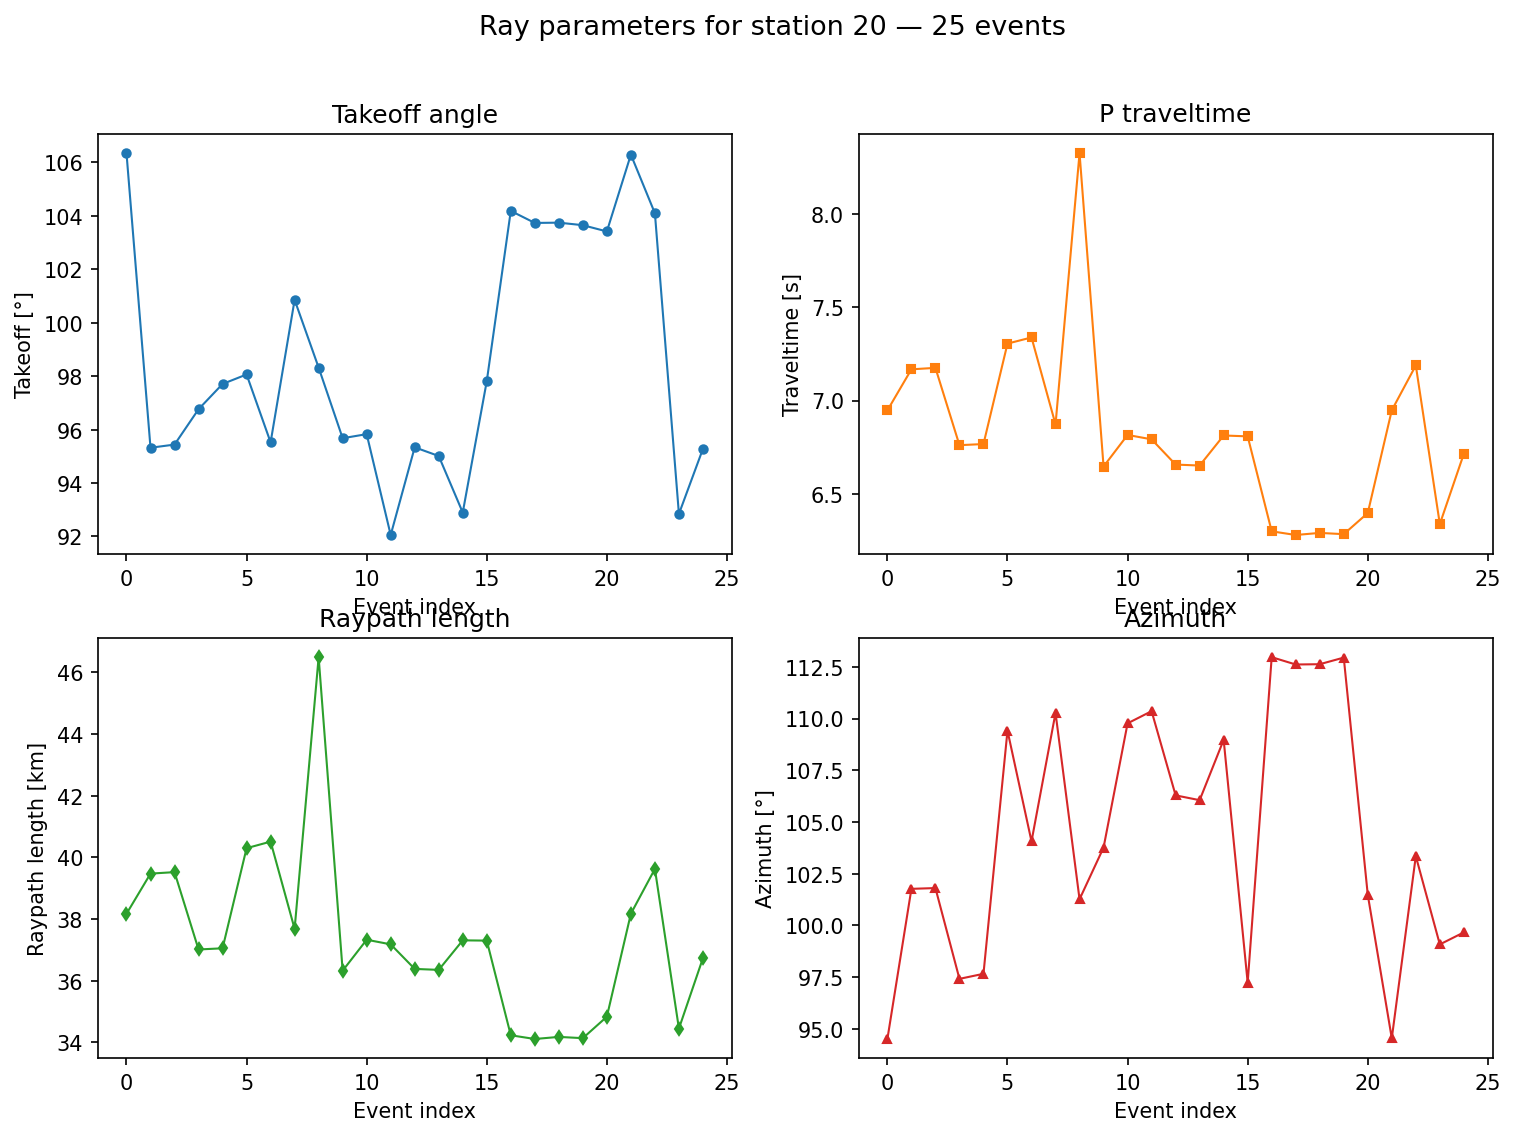

In [40]:
# --- Interpolate ray parameters at the demo station for all events ---
from dasfm.forward.eval_ray_lookup import interp_lookup_channels

# Use the in-memory RayParamDB from the previous cell directly — no disk I/O
pts = np.column_stack([source_z, source_x, source_y])
table_1sta = interp_lookup_channels(
    [db_sta],
    np.array([DEMO_STATION], dtype=np.int64),
    pts,
    forward_method="sta_2d",
    receiver_x=receiver_x_sta[DEMO_STATION:DEMO_STATION+1],
    receiver_y=receiver_y_sta[DEMO_STATION:DEMO_STATION+1],
    verbose=False,
)
T_1sta   = table_1sta.traveltime[:, 0]
ito_1sta = table_1sta.takeoff[:, 0]
r_1sta   = table_1sta.raypath_length[:, 0]
az_1sta  = np.degrees(table_1sta.azimuth[:, 0])

print(f"Interpolated {n_ev} events for station {DEMO_STATION}")

# --- Plot 2x2 vs event index ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150)

axes[0, 0].plot(np.degrees(ito_1sta), 'o-', ms=4, lw=1)
axes[0, 0].set_xlabel("Event index"); axes[0, 0].set_ylabel("Takeoff [°]")
axes[0, 0].set_title("Takeoff angle")

axes[0, 1].plot(T_1sta, 's-', ms=4, lw=1, color='C1')
axes[0, 1].set_xlabel("Event index"); axes[0, 1].set_ylabel("Traveltime [s]")
axes[0, 1].set_title("P traveltime")

axes[1, 0].plot(r_1sta, 'd-', ms=4, lw=1, color='C2')
axes[1, 0].set_xlabel("Event index"); axes[1, 0].set_ylabel("Raypath length [km]")
axes[1, 0].set_title("Raypath length")

axes[1, 1].plot(az_1sta, '^-', ms=4, lw=1, color='C3')
axes[1, 1].set_xlabel("Event index"); axes[1, 1].set_ylabel("Azimuth [°]")
axes[1, 1].set_title("Azimuth")

fig.suptitle(f"Ray parameters for station {DEMO_STATION} — {n_ev} events", fontsize=13)
# fig.tight_layout()
plt.show()


## 5b. Scale Up: Compute All Station Ray Parameters

The demo above computed a single station. To prepare for the focal-mechanism
inversion (lab 3c), we need ray parameters for **all 38 stations**.

The production call below invokes `step1_sta_2d` — the same function that
`lab3_simplest_running` uses. It computes 2-D FSM ray lookups for every
station and saves a unified `RayParamTable` to
`cache/ray_params/table_sta_2d.h5`.



  step1_sta_2d — Compute STA ray parameters (2D FSM)

[1/6] Loading input data...  (method: STA 2D)

[2/6] Building Cartesian grid (dr=dz=0.2 km, depth_max=26.5 km)...
[build_model_grid]  origin (37.57345°N, -118.82709°E)
  x (north) [0.00 … 87.20] km  nx=437  dx=0.2 km
  y (east)  [0.00 … 87.40] km  ny=438  dy=0.2 km
  z (depth) [0.00 … 30.80] km  nz=155  dz=0.2 km
  h_max=4.310 km  (z=0 ↔ 4.310 km a.s.l., sea level at z=4.310 km)
  n_events=25  n_receivers=38


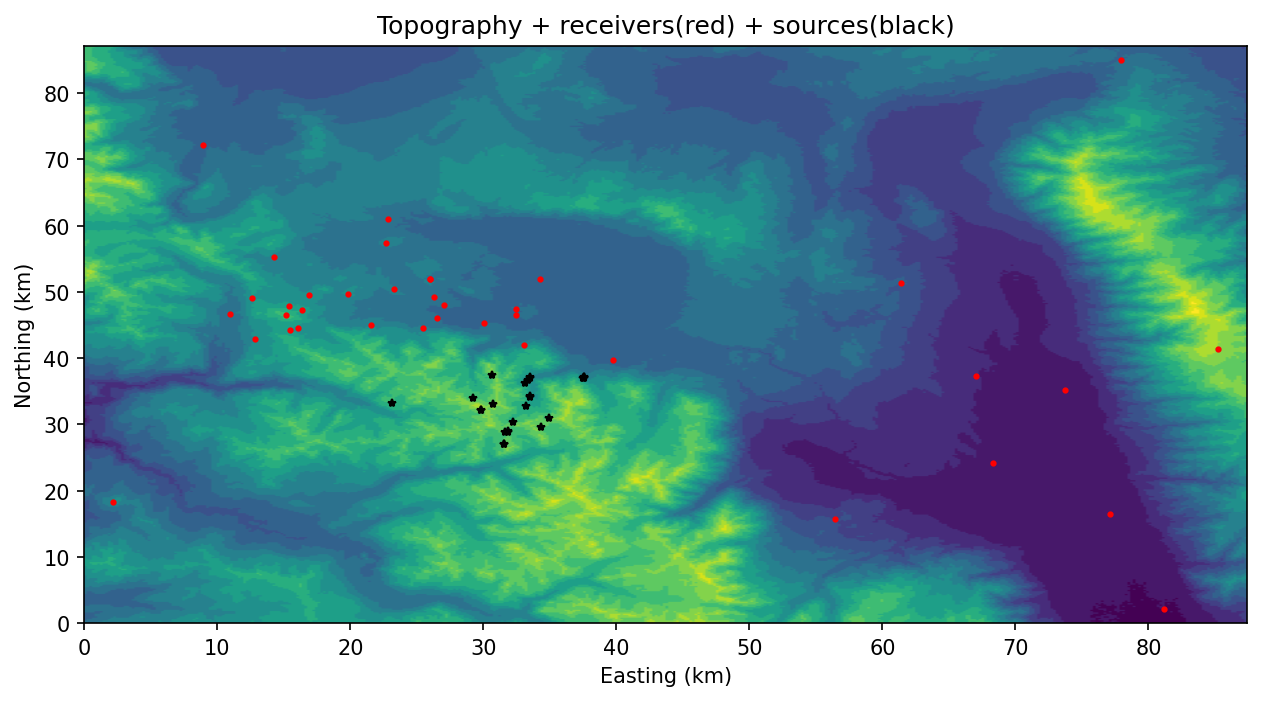

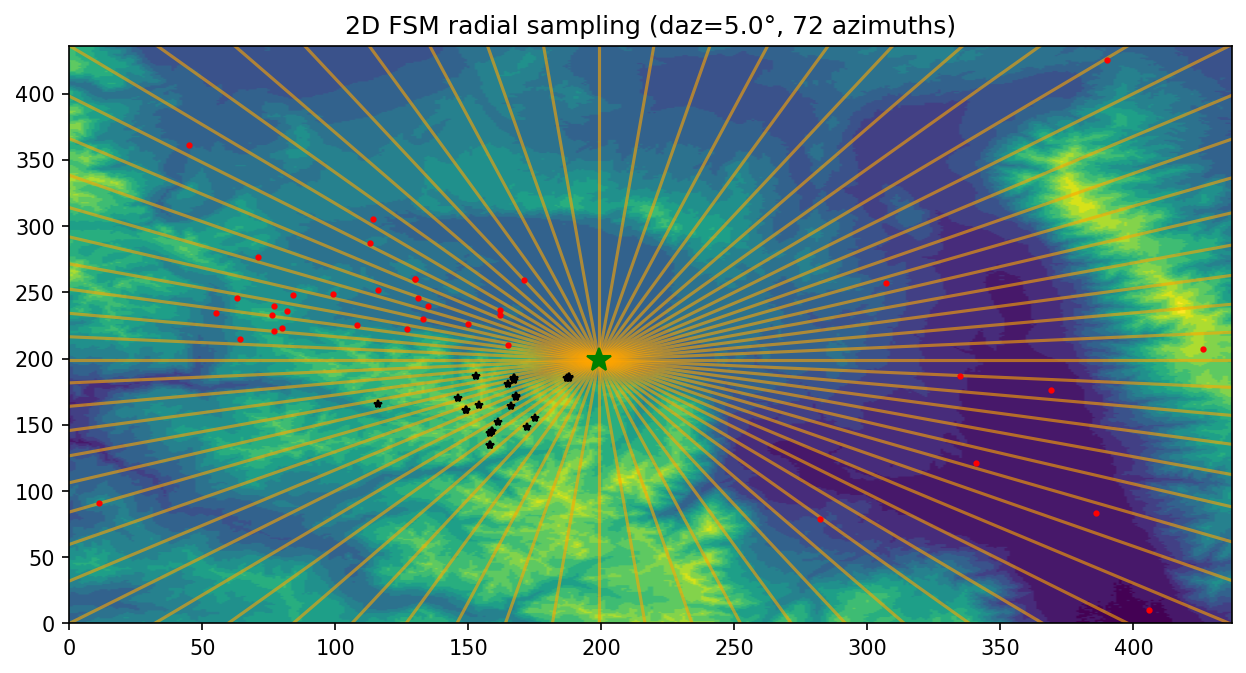


[3/6] Computing 2-D lookup tables for 38 stations...


stations: 100%|██████████| 38/38 [00:44<00:00,  1.16s/sta]



[4/6] Extracting source parameters...


Interpolating computed channels: 100%|██████████| 38/38 [00:04<00:00,  8.34it/s]



[6/6] Saving ray parameter table...
  → /home/tyan/joint_inversion/new_package/proj_25events/cache/ray_params/table_sta_2d.h5


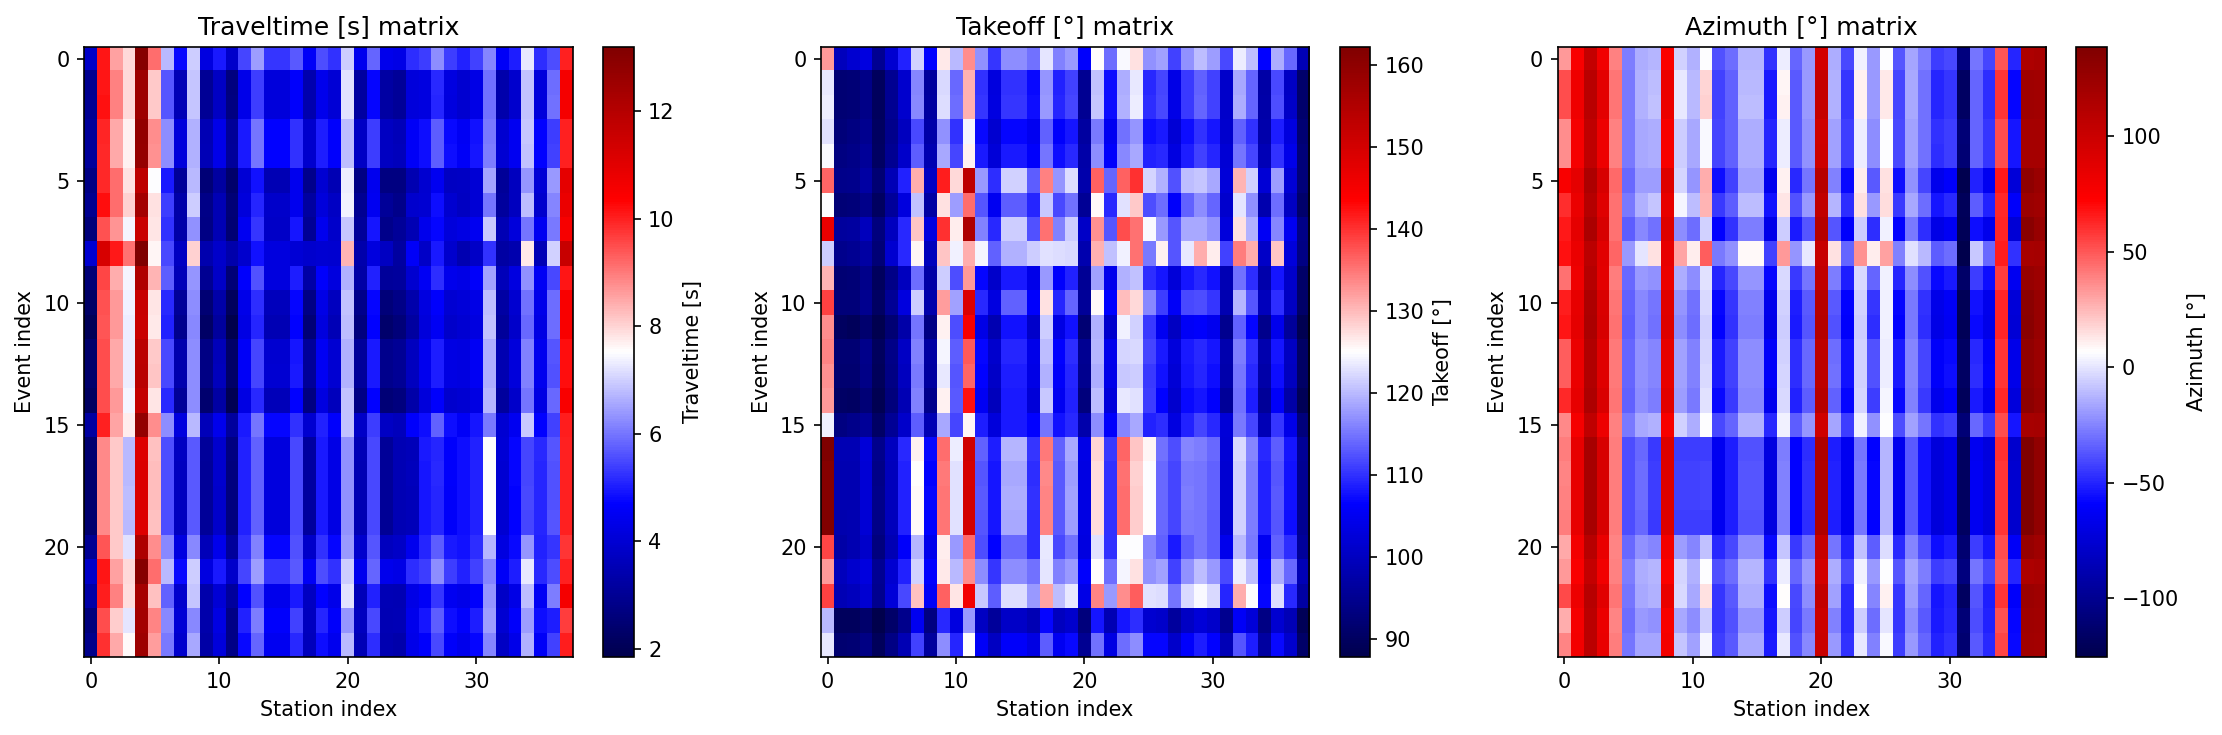

  → /home/tyan/joint_inversion/new_package/proj_25events/cache/figs/stage1_sta_2d  (3 plots)
  Done  (50.4 s)


In [41]:
from dasfm.steps import step1_sta_2d

step1_sta_2d(
    project_dir=str(PROJECT_DIR),
    event_catalog="input/catalog_25events.csv",
    sta_geo="input/all_stations.csv",
    vel_1d="input/1D_velocity_MAM.txt",
    topo="input/SRTMGL1_LongValley.tif",
    grid_spacing_km=dr,
    azimuth_interp_deg=daz,
    dasname="longvalley",
    show_plots=True,
)


## 6. Subsample DAS Channels

DAS fibers can have thousands of channels, but adjacent channels have nearly identical ray paths. We **subsample** the fiber to reduce computation while preserving spatial coverage:

- Every 20-th channel is selected as a computation point
- Channels at sharp fiber bends (> 5 degree) are excluded (unreliable coupling)
- The fiber layout QC plot shows selected vs. rejected channels, with a zoom inset at the sharpest bend


[subsample_das_channels]  n_ch=4670  dc=20  smooth_window=20  cum_bend_threshold=20.0°
  uniform: 235  cum-bends: 179  union: 404  (compression 11.6×)
Subsampled DAS channels: 404 / 4670


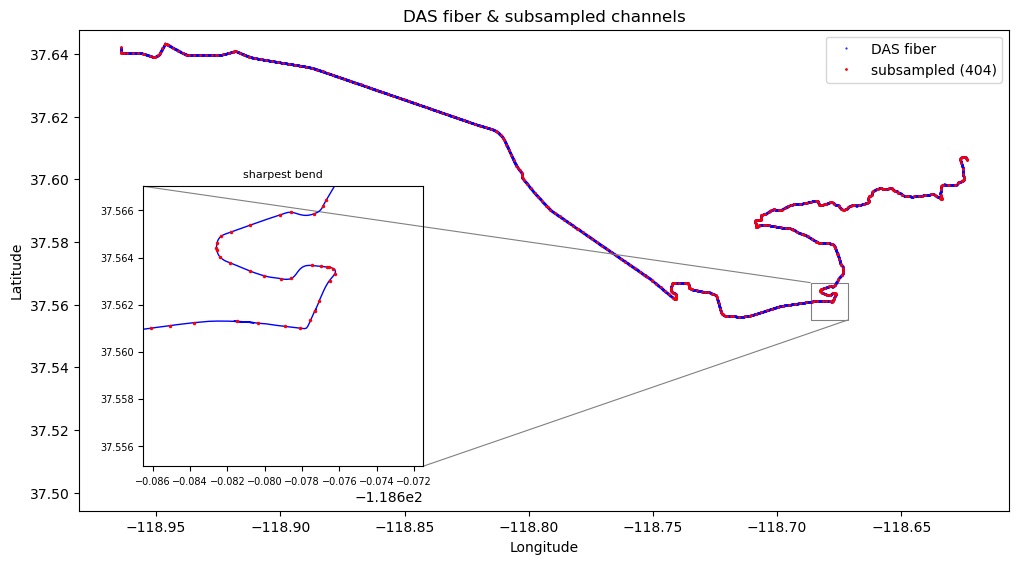

In [31]:
from dasfm.forward.channel_selection import subsample_das_channels

dc = 20                    # subsample interval
bend_threshold_deg = 20.0   # fiber bend threshold
smooth_window = 20


sample_channel = subsample_das_channels(
    receiver_x=geo_das['receiver_x'], receiver_y=geo_das['receiver_y'],
    dc=dc, bend_threshold_deg=bend_threshold_deg, smooth_window=smooth_window,
)
print(f"Subsampled DAS channels: {len(sample_channel)} / {n_ch}")

# Fiber layout QC
lon_min, lon_max = das_lon.min(), das_lon.max()
lat_min, lat_max = das_lat.min(), das_lat.max()
pad_lon = (lon_max - lon_min) * 0.05
pad_lat = (lat_max - lat_min) * 0.05
cos_lat = np.cos(np.radians(0.5 * (lat_min + lat_max)))

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(das_lon, das_lat, 'b.', ms=1, label='DAS fiber')
ax.plot(das_lon[sample_channel], das_lat[sample_channel],
        'r.', ms=2, label=f'subsampled ({len(sample_channel)})')
ax.set_xlim(lon_min - pad_lon, lon_max + pad_lon)
ax.set_ylim(lat_min - pad_lat, lat_max + pad_lat)
ax.set_aspect(1.0 / cos_lat, adjustable='box')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('DAS fiber & subsampled channels'); ax.legend()

y_lo, y_hi = ax.get_ylim()
y_range = y_hi - y_lo
ax.set_ylim(y_lo - 0.6 * y_range, y_hi)

dx_f = np.diff(das_lon); dy_f = np.diff(das_lat)
angles = np.arctan2(dy_f, dx_f)
dangle = np.abs(np.diff(angles))
dangle = np.minimum(dangle, 2 * np.pi - dangle)
dangle_smooth = uniform_filter1d(dangle, size=50)
i_peak = np.argmax(dangle_smooth)
center_lon, center_lat = das_lon[i_peak], das_lat[i_peak]
zoom_r = 0.0075

axins = fig.add_axes([0.12, 0.25, 0.35, 0.35])
axins.plot(das_lon, das_lat, 'b-', lw=1)
axins.plot(das_lon[sample_channel], das_lat[sample_channel], 'r.', ms=3)
axins.set_xlim(center_lon - zoom_r, center_lon + zoom_r)
axins.set_ylim(center_lat - zoom_r * cos_lat, center_lat + zoom_r * cos_lat)
axins.set_aspect(1.0 / cos_lat, adjustable='box')
axins.set_title('sharpest bend', fontsize=8); axins.tick_params(labelsize=7)
mark_inset(ax, axins, loc1=2, loc2=4, fc='none', ec='0.5', lw=0.8)
plt.show()

## 7. Compute Ray Catalog — DAS Channels (2D FSM)

Same workflow as Section 4, but for DAS channels. Each **subsampled** channel gets its own 2D FSM ray catalog. The interpolated ray parameters for one channel are shown in a 2x2 plot.


[Demo] Computing 2-D lookup table for DAS channel 0 (of 404 subsampled)...
[Demo] DAS channel 0 lookup computed: geometry=cyl_2d
Interpolated 25 events for DAS channel 0


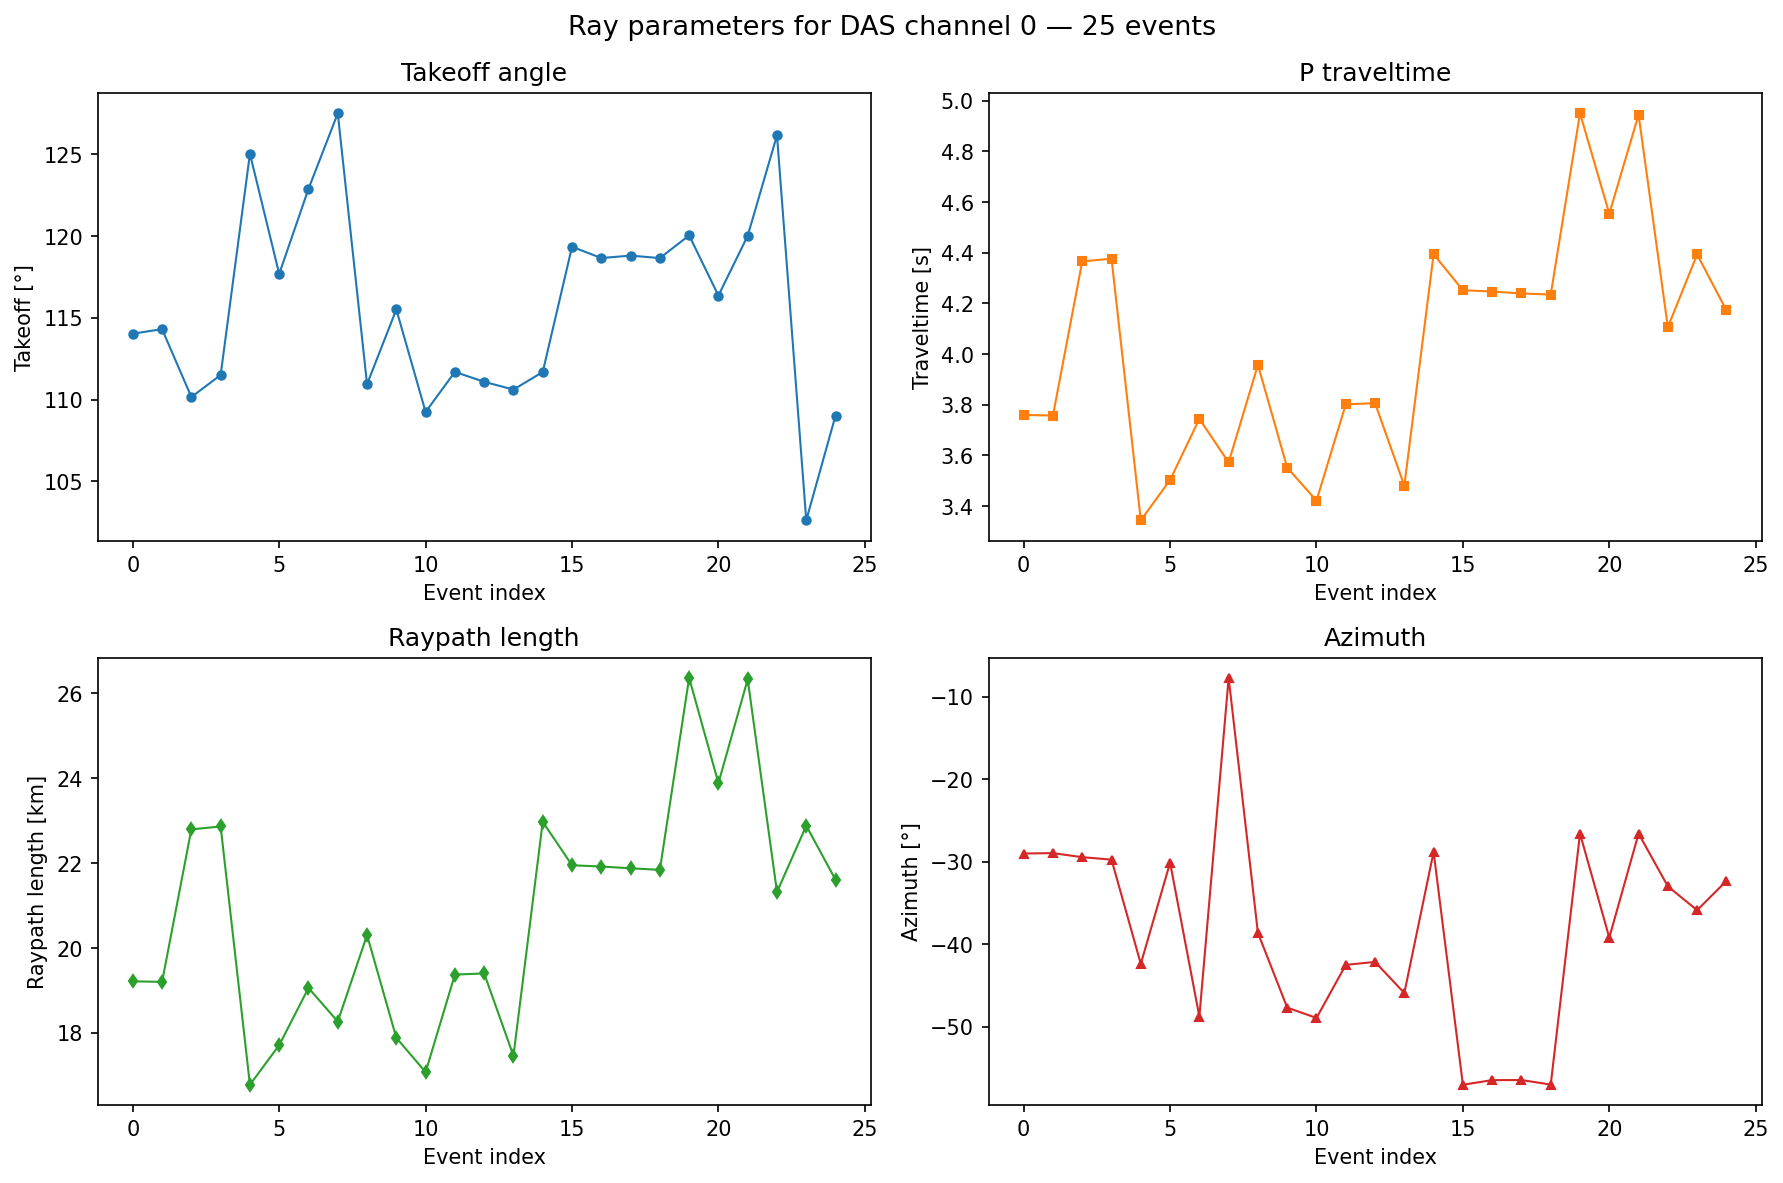

In [32]:
# DAS forward computation — DEMO: compute 1 channel and interpolate all events
from dasfm.forward.geometry import compute_fiber_orientation

DEMO_CHANNEL = sample_channel[0]  # <-- change this to compute a different channel

source_x_d = np.asarray(geo_das["source_x"], dtype=np.float64).ravel()
source_y_d = np.asarray(geo_das["source_y"], dtype=np.float64).ravel()
source_z_d = np.asarray(geo_das["source_z"], dtype=np.float64).ravel()

receiver_x_das = np.asarray(geo_das["receiver_x"], dtype=np.float64).ravel()
receiver_y_das = np.asarray(geo_das["receiver_y"], dtype=np.float64).ravel()

# --- Demo: compute one DAS channel lookup ---
print(f"[Demo] Computing 2-D lookup table for DAS channel {DEMO_CHANNEL} (of {len(sample_channel)} subsampled)...")
db_das = compute_ray_lookup(
    geo=geo_das,
    receiver_ix=geo_das['receiver_ix'][DEMO_CHANNEL],
    receiver_iy=geo_das['receiver_iy'][DEMO_CHANNEL],
    receiver_iz=geo_das['receiver_iz'][DEMO_CHANNEL],
    vel_1d_depth=vel_depth, vel_1d_vp=vel_vp,
    dr=dr, daz=daz,
)
print(f"[Demo] DAS channel {DEMO_CHANNEL} lookup computed: geometry={db_das.geometry}")

# --- Interpolate all events for this one channel (in-memory, no disk I/O) ---
pts_das = np.column_stack([source_z_d, source_x_d, source_y_d])
table_1ch = interp_lookup_channels(
    [db_das],
    np.array([DEMO_CHANNEL], dtype=np.int64),
    pts_das,
    forward_method="das_2d",
    receiver_x=receiver_x_das[DEMO_CHANNEL:DEMO_CHANNEL+1],
    receiver_y=receiver_y_das[DEMO_CHANNEL:DEMO_CHANNEL+1],
    verbose=False,
)
T_1ch   = table_1ch.traveltime[:, 0]
ito_1ch = table_1ch.takeoff[:, 0]
r_1ch   = table_1ch.raypath_length[:, 0]
az_1ch  = np.degrees(table_1ch.azimuth[:, 0])
n_ev_d = len(source_x_d)
print(f"Interpolated {n_ev_d} events for DAS channel {DEMO_CHANNEL}")

# --- Plot 2x2 vs event index ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150)

axes[0, 0].plot(np.degrees(ito_1ch), 'o-', ms=4, lw=1)
axes[0, 0].set_xlabel("Event index"); axes[0, 0].set_ylabel("Takeoff [°]")
axes[0, 0].set_title("Takeoff angle")

axes[0, 1].plot(T_1ch, 's-', ms=4, lw=1, color='C1')
axes[0, 1].set_xlabel("Event index"); axes[0, 1].set_ylabel("Traveltime [s]")
axes[0, 1].set_title("P traveltime")

axes[1, 0].plot(r_1ch, 'd-', ms=4, lw=1, color='C2')
axes[1, 0].set_xlabel("Event index"); axes[1, 0].set_ylabel("Raypath length [km]")
axes[1, 0].set_title("Raypath length")

axes[1, 1].plot(az_1ch, '^-', ms=4, lw=1, color='C3')
axes[1, 1].set_xlabel("Event index"); axes[1, 1].set_ylabel("Azimuth [°]")
axes[1, 1].set_title("Azimuth")

fig.suptitle(f"Ray parameters for DAS channel {DEMO_CHANNEL} — {n_ev_d} events", fontsize=13)
fig.tight_layout()
plt.show()


In [33]:
# ── Compute 2D ray lookups for ALL subsampled DAS channels and save the
#    Layer-2 RayParamTable that step3 will read.
from dasfm.io.data import RayParamTable

LUT_DIR_DAS = CACHE_DIR / "ray_params/das_2d"
LUT_DIR_DAS.mkdir(parents=True, exist_ok=True)

print(f"Computing 2D ray lookups for {len(sample_channel)} subsampled DAS channels...")
t0 = time.time()
for idc in tqdm(sample_channel, desc="channels", unit="ch"):
    out_path = LUT_DIR_DAS / f"das_channel_{idc:05d}.h5"
    if out_path.exists():
        continue  # reuse existing lookup
    db = compute_ray_lookup(
        geo=geo_das,
        receiver_ix=geo_das['receiver_ix'][idc],
        receiver_iy=geo_das['receiver_iy'][idc],
        receiver_iz=geo_das['receiver_iz'][idc],
        vel_1d_depth=vel_depth, vel_1d_vp=vel_vp,
        dr=dr, daz=daz,
        receiver_x_exact=float(receiver_x_das[idc]),
        receiver_y_exact=float(receiver_y_das[idc]),
        verbose=False,
    )
    db.to_hdf5(out_path)
print(f"  Per-receiver volumes done in {time.time() - t0:.1f} s  →  {LUT_DIR_DAS}")

# ── Build the Layer-2+3 RayParamTable for ALL DAS channels using
#    interp_lookup_channels (it linearly fills missing channels via
#    n_ch_total).
files_sub  = sorted(LUT_DIR_DAS.glob("das_channel_*.h5"))
ch_ids_sub = np.array([int(f.stem.split("_")[-1]) for f in files_sub], dtype=np.int64)
pts_sub    = np.column_stack([source_z_d, source_x_d, source_y_d])
n_ch_total = len(receiver_x_das)

azi_fiber_deg = compute_fiber_orientation(receiver_x_das, receiver_y_das)
rec_azi = np.deg2rad(azi_fiber_deg).astype(np.float32)

table_das = interp_lookup_channels(
    files_sub, ch_ids_sub, pts_sub,
    forward_method="das_2d",
    receiver_x=receiver_x_das,
    receiver_y=receiver_y_das,
    n_ch_total=n_ch_total,
    rec_azi=rec_azi,
    verbose=True,
)
print(f"DAS ray params table: takeoff {table_das.takeoff.shape}  (n_ev, n_ch)")

# ── Save Layer-2+3 unified table ──
table_path = CACHE_DIR / "ray_params" / "table_das_2d.h5"
table_das.to_hdf5(table_path)
print(f"Saved  →  {table_path}")


Computing 2D ray lookups for 404 subsampled DAS channels...


channels: 100%|██████████| 404/404 [02:35<00:00,  2.59ch/s]


  Per-receiver volumes done in 155.7 s  →  ../proj_25events/cache/ray_params/das_2d


Interpolating computed channels: 100%|██████████| 404/404 [00:16<00:00, 24.62it/s]

DAS ray params table: takeoff (25, 4670)  (n_ev, n_ch)
Saved  →  ../proj_25events/cache/ray_params/table_das_2d.h5


## 8. Interpolation to All DAS Channels

The ray catalogs are computed only for the **subsampled** channels (e.g., 330 out of 4670). To obtain ray parameters for **all** channels, we use linear interpolation along the fiber axis:

1. For each subsampled channel: trilinear interpolation in the cylindrical catalog -> ray parameters per event
2. Stack into a sparse matrix: (n_ev, n_computed)
3. Linear interpolation along channel axis: (n_ev, n_computed) -> (n_ev, n_ch_total)

DAS ray params (all events x all channels): traveltime (25, 4670)


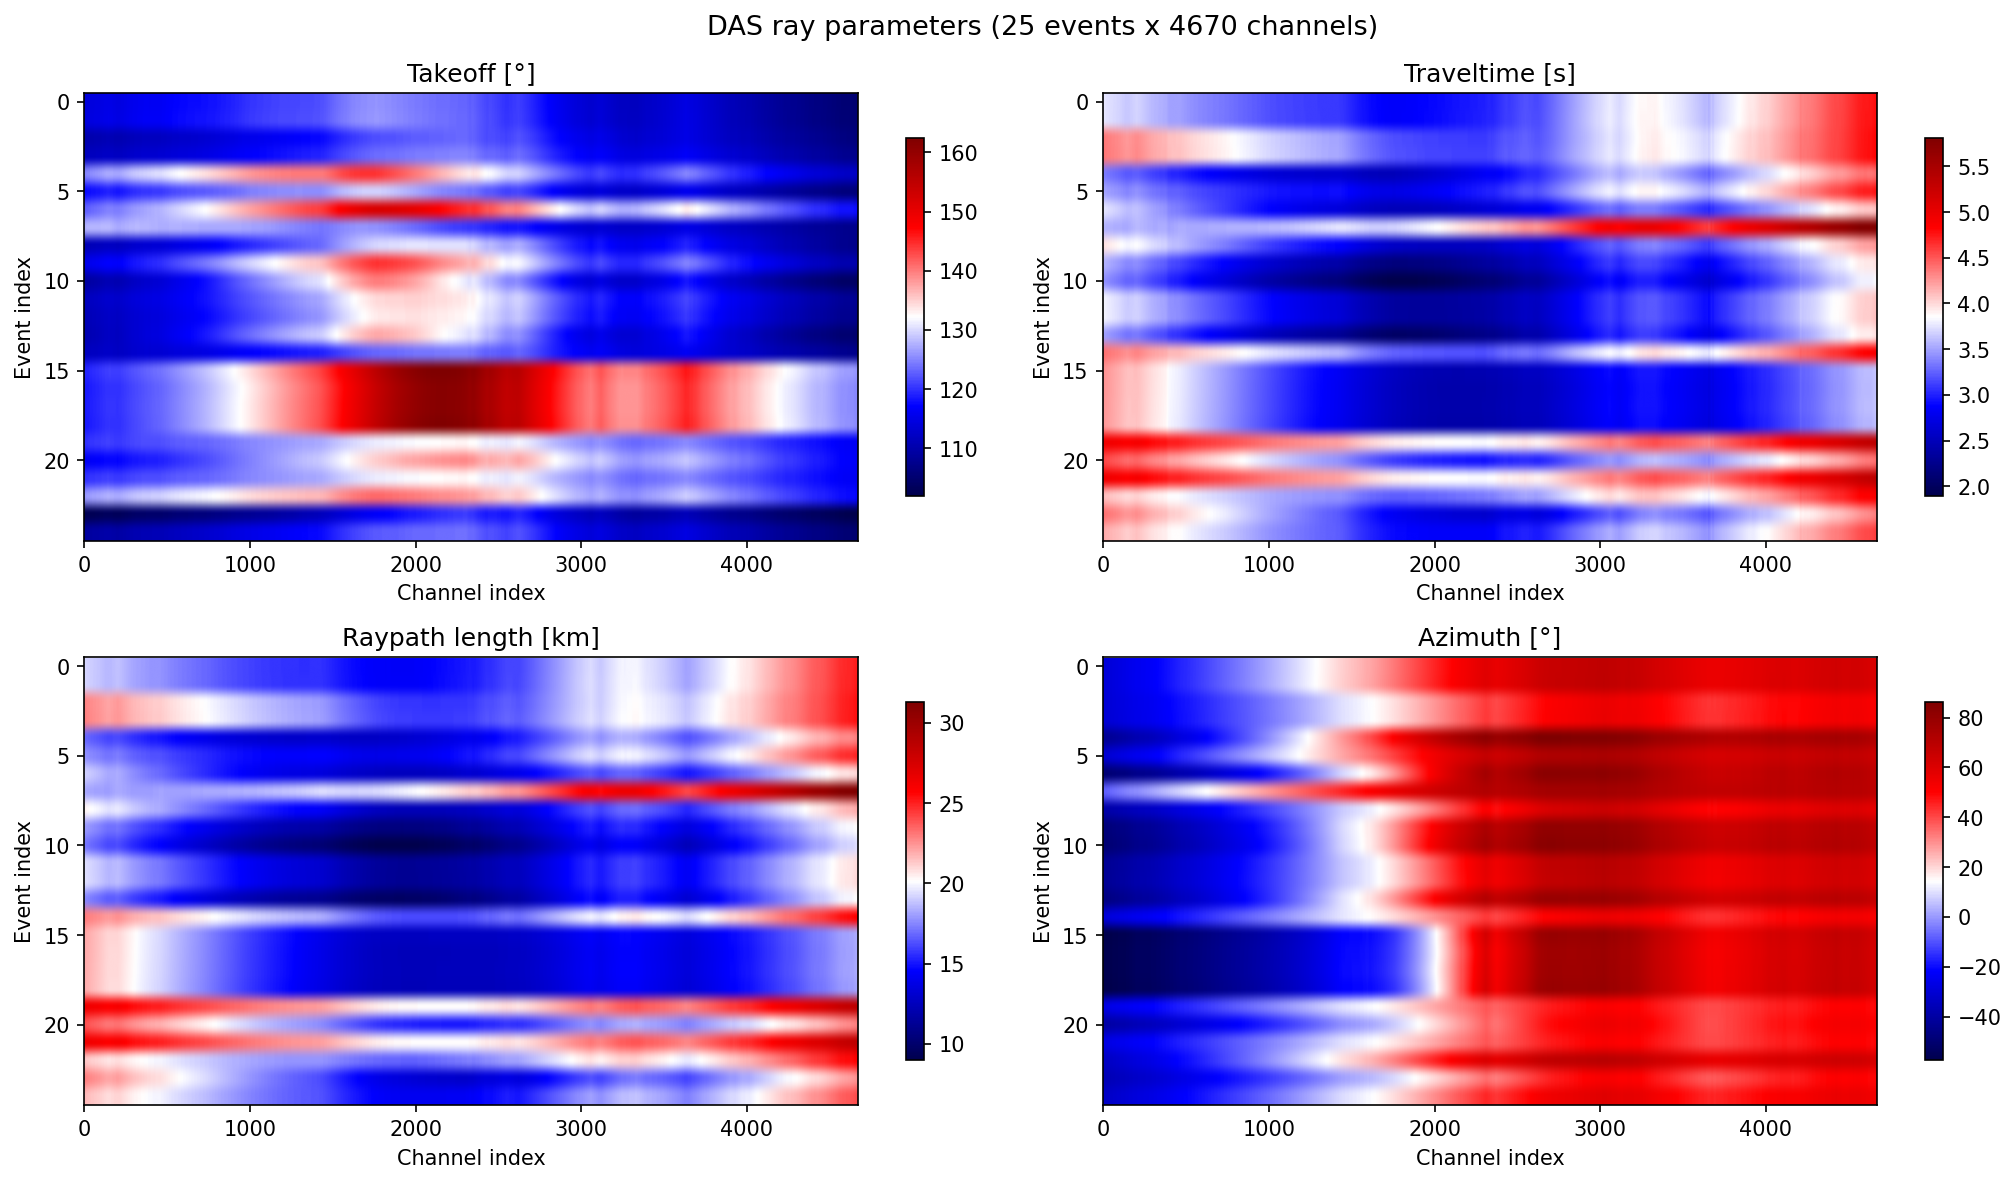

In [34]:
# --- Inspect the per-event-per-channel ray parameters loaded back from disk ---
from dasfm.io.data import RayParamTable

table_loaded = RayParamTable.from_hdf5(CACHE_DIR / "ray_params" / "table_das_2d.h5")
T_all   = table_loaded.traveltime
ito_all = table_loaded.takeoff
r_all   = table_loaded.raypath_length
az_all  = table_loaded.azimuth

print(f"DAS ray params (all events x all channels): traveltime {T_all.shape}")

# --- Interpolated DAS ray parameters (all events x all channels) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=150)

data_list = [np.degrees(ito_all), T_all, r_all, np.degrees(az_all)]
titles = ["Takeoff [°]", "Traveltime [s]", "Raypath length [km]", "Azimuth [°]"]

for ax, data, title in zip(axes.ravel(), data_list, titles):
    im = ax.imshow(data, aspect="auto", cmap="seismic", origin="upper")
    ax.set_xlabel("Channel index"); ax.set_ylabel("Event index")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(f"DAS ray parameters ({T_all.shape[0]} events x {T_all.shape[1]} channels)", fontsize=13)
fig.tight_layout()
plt.show()
